# 03 · Variable Target — Procesamiento de Fenotipos AMR

**Objetivo:** Construir el vector de etiquetas `y` para el problema de clasificación binaria
Susceptible (0) vs Resistente (1) a ciprofloxacino en *Klebsiella pneumoniae*.

| Paso | Descripción |
|---|---|
| 1 | Carga de fenotipos brutos + IDs que pasaron el QC genómico |
| 2 | Análisis exploratorio: distribución S/I/R y valores MIC |
| 3 | Validación con breakpoints EUCAST v14 para ciprofloxacino |
| 4 | Resolución de fenotipos Intermedios (I) |
| 5 | Construcción del target binario y detección de inconsistencias |
| 6 | Guardado de `y_final.npy` y `target_metadata.csv` |

**Input:**
- `datos/brutos/amr_fenotipos.csv` — etiquetas S/I/R + MIC por genoma y antibiótico
- `datos/procesados/ids_qc_ok.json` — IDs que superaron el QC (notebook 02)

**Output:**
- `datos/procesados/y_final.npy` — array (N,) con 0=S, 1=R
- `datos/procesados/target_metadata.csv` — genome_id, label, mic_value, mic_sign, fuente_label
- `datos/procesados/informe_target.json` — resumen reproducible del proceso
- `informes/figuras/03_*.png` — figuras EDA del target

---
### Nota sobre breakpoints EUCAST v14 — Ciprofloxacino / *K. pneumoniae*

| Categoría | Criterio MIC (mg/L) | Acción en este pipeline |
|---|---|---|
| S (Susceptible) | ≤ 0.25 | Etiqueta 0 |
| I (Intermedio) | 0.25 < MIC ≤ 0.5 | Ver Celda 4 |
| R (Resistant) | > 0.5 | Etiqueta 1 |

> **EUCAST 2019** eliminó la categoría I tradicional y la redefinió como
> *Susceptible, Increased Exposure* (SIE). En la práctica clínica y en la
> mayoría de los estudios AMR-ML se excluyen o se reclasifican como R
> (enfoque conservador). Este notebook implementa **ambas estrategias** y
> guarda el resultado de la estrategia seleccionada en `y_final.npy`.

---
## Celda 0 — Imports y configuración global

In [1]:
# ─── Librería estándar ────────────────────────────────────────────────────────
import json
import logging
from pathlib import Path
from datetime import datetime

# ─── Third-party ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# ─── Rutas del proyecto ───────────────────────────────────────────────────────
ROOT      = Path.cwd().parent
DIR_BRUT  = ROOT / "datos" / "brutos"
DIR_PROC  = ROOT / "datos" / "procesados"
DIR_FIGS  = ROOT / "informes" / "figuras"

for d in [DIR_PROC, DIR_FIGS]:
    d.mkdir(parents=True, exist_ok=True)

# ─── Parámetros ───────────────────────────────────────────────────────────────
ANTIBIOTICO = "ciprofloxacin"

# Breakpoints EUCAST v14.0 — Ciprofloxacino / Enterobacterales (K. pneumoniae)
# https://www.eucast.org/clinical_breakpoints/
EUCAST_S_MIC   = 0.25   # S si MIC ≤ 0.25 mg/L
EUCAST_R_MIC   = 0.5    # R si MIC > 0.5 mg/L  (I: 0.25 < MIC ≤ 0.5)

# Estrategia para fenotipos Intermedios:
#   'exclude' → eliminar del dataset (más limpio, menos datos)
#   'as_R'    → reclasificar como Resistente (enfoque conservador clínico)
ESTRATEGIA_I = "exclude"   # ← cambiar aquí si se quiere probar 'as_R'

# Estilo gráfico
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

print(f"Proyecto raíz : {ROOT}")
print(f"Timestamp     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Antibiótico   : {ANTIBIOTICO}")
print(f"Breakpoints   : S ≤ {EUCAST_S_MIC} | I ({EUCAST_S_MIC}–{EUCAST_R_MIC}] | R > {EUCAST_R_MIC} mg/L")
print(f"Estrategia I  : {ESTRATEGIA_I}")

Proyecto raíz : /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction
Timestamp     : 2026-03-18 13:42:59
Antibiótico   : ciprofloxacin
Breakpoints   : S ≤ 0.25 | I (0.25–0.5] | R > 0.5 mg/L
Estrategia I  : exclude


---
## Celda 1 — Carga de datos

Cargamos el CSV de fenotipos brutos y filtramos por:
1. Antibiótico = ciprofloxacino
2. IDs que pasaron el QC genómico (notebook 02)

In [2]:
# ── 1a. Cargar IDs que pasaron el QC genómico ─────────────────────────────────
ruta_ids = DIR_PROC / "ids_qc_ok.json"
assert ruta_ids.exists(), (
    f"No se encuentra {ruta_ids}\n"
    "→ Ejecuta el notebook 02 (control_calidad_genomica) primero."
)

with open(ruta_ids) as f:
    ids_qc_ok = set(json.load(f))

log.info(f"IDs con QC OK: {len(ids_qc_ok)}")

# ── 1b. Cargar CSV de fenotipos brutos ───────────────────────────────────────
ruta_fenotipos = DIR_BRUT / "amr_fenotipos.csv"
assert ruta_fenotipos.exists(), (
    f"No se encuentra {ruta_fenotipos}\n"
    "→ Ejecuta el notebook 01 (descarga_datos) primero."
)

df_raw = pd.read_csv(ruta_fenotipos, dtype={"genome_id": str})
log.info(f"Fenotipos brutos cargados: {len(df_raw):,} filas, {df_raw.shape[1]} columnas")

print("\nColumnas disponibles:")
print(df_raw.columns.tolist())
print("\nPrimeras filas:")
df_raw.head(3)

13:43:01 [INFO] IDs con QC OK: 565
13:43:01 [INFO] Fenotipos brutos cargados: 10,000 filas, 10 columnas



Columnas disponibles:
['antibiotic', 'resistant_phenotype', 'genome_id', 'genome_name', 'measurement_value', 'laboratory_typing_method', 'testing_standard', 'measurement_unit', 'measurement_sign', 'laboratory_typing_platform']

Primeras filas:


,antibiotic,resistant_phenotype,genome_id,genome_name,measurement_value,laboratory_typing_method,testing_standard,measurement_unit,measurement_sign,laboratory_typing_platform
0,ciprofloxacin,Susceptible,573.10001,Klebsiella pneumoniae strain VRCO0337,NaN,NaN,NaN,NaN,NaN,NaN
1,ciprofloxacin,Susceptible,573.10005,Klebsiella pneumoniae strain VRCO0408,NaN,NaN,NaN,NaN,NaN,NaN
2,ciprofloxacin,Susceptible,573.10008,Klebsiella pneumoniae strain VRCO0411,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── 1c. Filtrar por antibiótico + IDs con QC OK ───────────────────────────────
#
# BV-BRC usa 'antibiotic' como nombre de columna con valores en minúscula.
# El campo 'resistant_phenotype' toma valores: Susceptible / Resistant / Intermediate
# El campo 'measurement_value' es el valor MIC numérico (puede ser NaN)
# El campo 'measurement_sign' es el operador: '=', '<=', '>=' (dilución en broth microdilution)

# Normalizar nombre del antibiótico por si hay variantes de capitalización
df_raw["antibiotic"] = df_raw["antibiotic"].str.lower().str.strip()

# Filtro 1: antibiótico objetivo
df_cipro = df_raw[df_raw["antibiotic"] == ANTIBIOTICO].copy()
log.info(f"Registros para {ANTIBIOTICO}: {len(df_cipro):,}")

# Filtro 2: IDs que pasaron QC
df_cipro = df_cipro[df_cipro["genome_id"].astype(str).isin(ids_qc_ok)].copy()
log.info(f"Tras filtro QC: {len(df_cipro):,} registros / {df_cipro['genome_id'].nunique()} genomas únicos")

# ── Sanidad: ¿hay genomas con múltiples registros para el mismo antibiótico? ──
duplicados = df_cipro.groupby("genome_id").size()
n_dup = (duplicados > 1).sum()

if n_dup > 0:
    log.warning(
        f"{n_dup} genomas tienen >1 registro para {ANTIBIOTICO} "
        "→ se mantendrá el de mayor prioridad (ver Celda 3)"
    )
    print(f"\n⚠️  Genomas con registros duplicados: {n_dup}")
    print(duplicados[duplicados > 1].head(10))
else:
    log.info("Sin duplicados — cada genoma tiene exactamente 1 registro")
    print("✓ Sin duplicados")

print(f"\nDistribución de fenotipos (bruta, pre-resolución):")
print(df_cipro["resistant_phenotype"].value_counts())

13:43:04 [INFO] Registros para ciprofloxacin: 10,000
13:43:04 [INFO] Tras filtro QC: 744 registros / 565 genomas únicos
13:43:04 [WARNING] 179 genomas tienen >1 registro para ciprofloxacin → se mantendrá el de mayor prioridad (ver Celda 3)



⚠️  Genomas con registros duplicados: 179
genome_id
573.12796    2
573.12863    2
573.12893    2
573.12902    2
573.12912    2
573.12961    2
573.12965    2
573.12969    2
573.12998    2
573.13002    2
dtype: int64

Distribución de fenotipos (bruta, pre-resolución):
resistant_phenotype
Resistant       400
Susceptible     337
Intermediate      7
Name: count, dtype: int64


---
## Celda 2 — EDA del target: distribución de fenotipos y MIC

Antes de tomar ninguna decisión sobre los Intermedios, entendemos el dato:
- ¿Cuántos S/I/R tenemos?
- ¿Qué fracción tiene valor MIC medido?
- ¿La distribución MIC es consistente con los breakpoints EUCAST?

In [4]:
# ── 2a. Distribución S/I/R ────────────────────────────────────────────────────
conteo_sir = df_cipro["resistant_phenotype"].value_counts()
pct_sir    = df_cipro["resistant_phenotype"].value_counts(normalize=True) * 100

print("=" * 45)
print("DISTRIBUCIÓN DE FENOTIPOS (S/I/R)")
print("=" * 45)
for cat in ["Susceptible", "Intermediate", "Resistant"]:
    n   = conteo_sir.get(cat, 0)
    pct = pct_sir.get(cat, 0.0)
    print(f"  {cat:<15}: {n:>4}  ({pct:.1f}%)")
print(f"  {'Total':<15}: {len(df_cipro):>4}")

# Cobertura de MIC
n_con_mic = df_cipro["measurement_value"].notna().sum()
pct_mic   = n_con_mic / len(df_cipro) * 100
print(f"\n  Registros con MIC medido : {n_con_mic} ({pct_mic:.1f}%)")
print(f"  Registros sin MIC        : {len(df_cipro) - n_con_mic}")

DISTRIBUCIÓN DE FENOTIPOS (S/I/R)
  Susceptible    :  337  (45.3%)
  Intermediate   :    7  (0.9%)
  Resistant      :  400  (53.8%)
  Total          :  744

  Registros con MIC medido : 141 (19.0%)
  Registros sin MIC        : 603


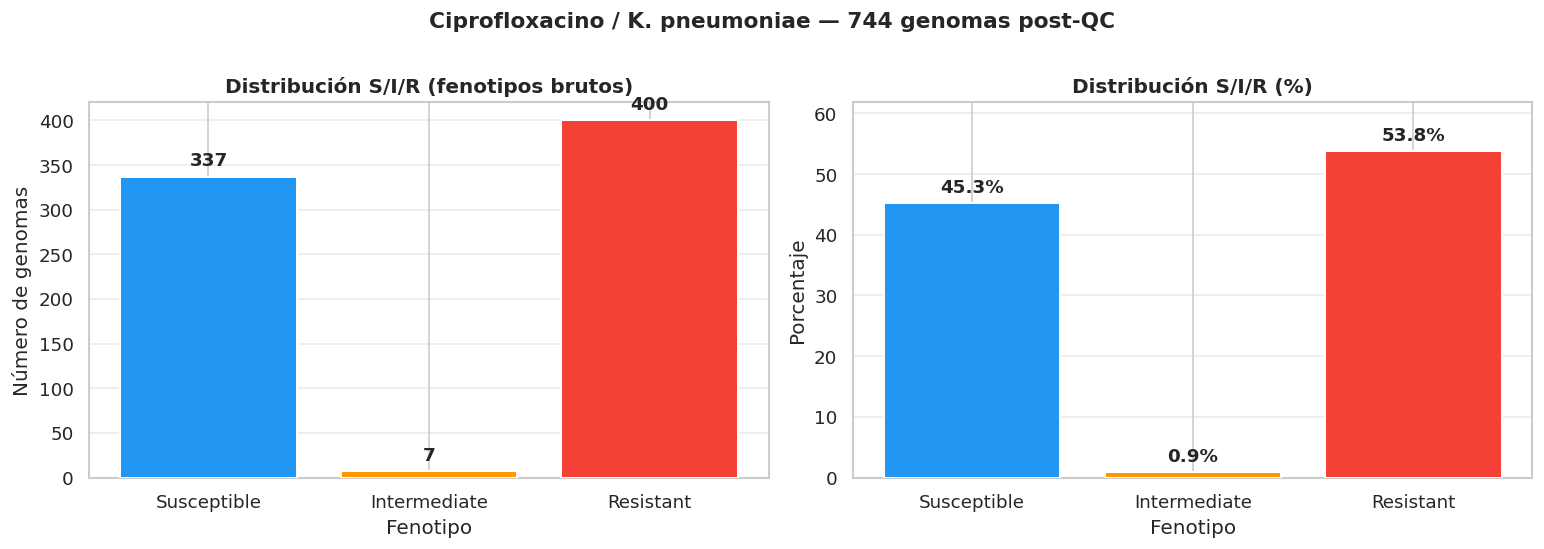

13:43:14 [INFO] Figura guardada → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/informes/figuras/03_distribucion_sir.png


In [5]:
# ── 2b. Figura 1: Barplot S/I/R ───────────────────────────────────────────────
COLORES_SIR = {"Susceptible": "#2196F3", "Intermediate": "#FF9800", "Resistant": "#F44336"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# — Panel izquierdo: conteos —
ax = axes[0]
categorias = [c for c in ["Susceptible", "Intermediate", "Resistant"] if c in conteo_sir.index]
valores    = [conteo_sir[c] for c in categorias]
colores    = [COLORES_SIR[c] for c in categorias]

bars = ax.bar(categorias, valores, color=colores, edgecolor="white", linewidth=1.2, zorder=3)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=11, fontweight="bold")
ax.set_title("Distribución S/I/R (fenotipos brutos)", fontweight="bold")
ax.set_ylabel("Número de genomas")
ax.set_xlabel("Fenotipo")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# — Panel derecho: porcentaje —
ax2 = axes[1]
pct_vals = [pct_sir.get(c, 0.0) for c in categorias]
bars2    = ax2.bar(categorias, pct_vals, color=colores, edgecolor="white", linewidth=1.2, zorder=3)
ax2.bar_label(bars2, fmt="%.1f%%", padding=4, fontsize=11, fontweight="bold")
ax2.set_title("Distribución S/I/R (%)", fontweight="bold")
ax2.set_ylabel("Porcentaje")
ax2.set_xlabel("Fenotipo")
ax2.set_ylim(0, max(pct_vals) * 1.15)
ax2.grid(axis="y", alpha=0.4, zorder=0)
ax2.set_axisbelow(True)

plt.suptitle(
    f"Ciprofloxacino / K. pneumoniae — {len(df_cipro)} genomas post-QC",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
ruta_fig1 = DIR_FIGS / "03_distribucion_sir.png"
plt.savefig(ruta_fig1, bbox_inches="tight", dpi=150)
plt.show()
log.info(f"Figura guardada → {ruta_fig1}")

In [6]:
# ── 2c. Figura 2: Distribución de valores MIC por categoría fenotípica ────────
#
# Filtramos los que tienen MIC medido. Los valores MIC son concentraciones
# en mg/L que siguen una escala log2 estándar (diluciones dobles):
# 0.015, 0.03, 0.06, 0.125, 0.25, 0.5, 1, 2, 4, 8, 16, 32 ...
#
# IMPORTANTE: measurement_sign ('<=', '>=', '=') indica el tipo de medición.
# Los valores con signo '>' o '>=' son MICs censurados por la derecha
# (el organismo creció incluso a la concentración máxima testada).
# Para la visualización los tratamos como valores numéricos directos,
# pero los documentamos.

df_mic = df_cipro[df_cipro["measurement_value"].notna()].copy()
df_mic["measurement_value"] = pd.to_numeric(df_mic["measurement_value"], errors="coerce")
df_mic = df_mic[df_mic["measurement_value"].notna()]

print(f"Registros con MIC numérico: {len(df_mic)}")
print(f"Rangos MIC por categoría:")
print(df_mic.groupby("resistant_phenotype")["measurement_value"].describe().round(3))

# Distribución de signos de medición
print("\nDistribución de measurement_sign:")
print(df_cipro["measurement_sign"].value_counts())

Registros con MIC numérico: 141
Rangos MIC por categoría:
                     count   mean    std   min  25%  50%  75%  max
resistant_phenotype                                               
Intermediate           6.0  2.000  0.000  2.00  2.0  2.0  2.0  2.0
Resistant            115.0  2.896  2.062  1.00  2.0  2.0  2.0  8.0
Susceptible           20.0  0.575  0.231  0.25  0.5  0.5  0.5  1.0

Distribución de measurement_sign:
measurement_sign
>     109
<=     16
>=      5
=       3
<       1
Name: count, dtype: int64


/tmp/ipykernel_1469/4278599228.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1469/4278599228.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


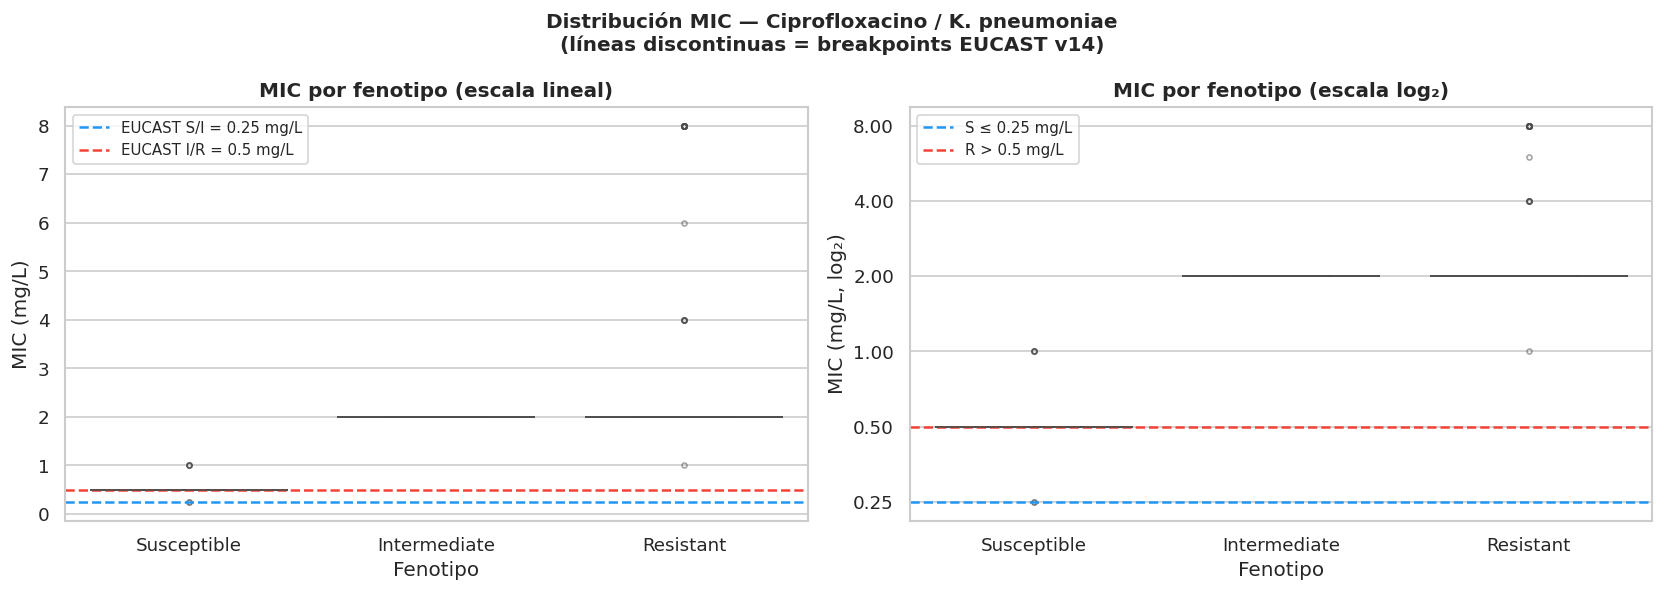

13:43:17 [INFO] Figura guardada → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/informes/figuras/03_mic_por_fenotipo.png


In [7]:
# ── 2d. Figura 3: Boxplot MIC por fenotipo + líneas de breakpoint EUCAST ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo — escala lineal (permite ver la zona S)
ax = axes[0]
orden = [c for c in ["Susceptible", "Intermediate", "Resistant"] if c in df_mic["resistant_phenotype"].unique()]
sns.boxplot(
    data=df_mic, x="resistant_phenotype", y="measurement_value",
    order=orden, palette=COLORES_SIR, ax=ax,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.5}
)
ax.axhline(EUCAST_S_MIC, color="#2196F3", linestyle="--", lw=1.5,
           label=f"EUCAST S/I = {EUCAST_S_MIC} mg/L")
ax.axhline(EUCAST_R_MIC, color="#F44336", linestyle="--", lw=1.5,
           label=f"EUCAST I/R = {EUCAST_R_MIC} mg/L")
ax.set_title("MIC por fenotipo (escala lineal)", fontweight="bold")
ax.set_xlabel("Fenotipo")
ax.set_ylabel("MIC (mg/L)")
ax.legend(fontsize=9)

# Panel derecho — escala log2 (escala natural de los ensayos MIC)
ax2 = axes[1]
sns.boxplot(
    data=df_mic, x="resistant_phenotype", y="measurement_value",
    order=orden, palette=COLORES_SIR, ax=ax2,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.5}
)
ax2.set_yscale("log", base=2)
ax2.axhline(EUCAST_S_MIC, color="#2196F3", linestyle="--", lw=1.5,
            label=f"S ≤ {EUCAST_S_MIC} mg/L")
ax2.axhline(EUCAST_R_MIC, color="#F44336", linestyle="--", lw=1.5,
            label=f"R > {EUCAST_R_MIC} mg/L")
ax2.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax2.set_title("MIC por fenotipo (escala log₂)", fontweight="bold")
ax2.set_xlabel("Fenotipo")
ax2.set_ylabel("MIC (mg/L, log₂)")
ax2.legend(fontsize=9)

plt.suptitle(
    "Distribución MIC — Ciprofloxacino / K. pneumoniae\n"
    "(líneas discontinuas = breakpoints EUCAST v14)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
ruta_fig2 = DIR_FIGS / "03_mic_por_fenotipo.png"
plt.savefig(ruta_fig2, bbox_inches="tight", dpi=150)
plt.show()
log.info(f"Figura guardada → {ruta_fig2}")

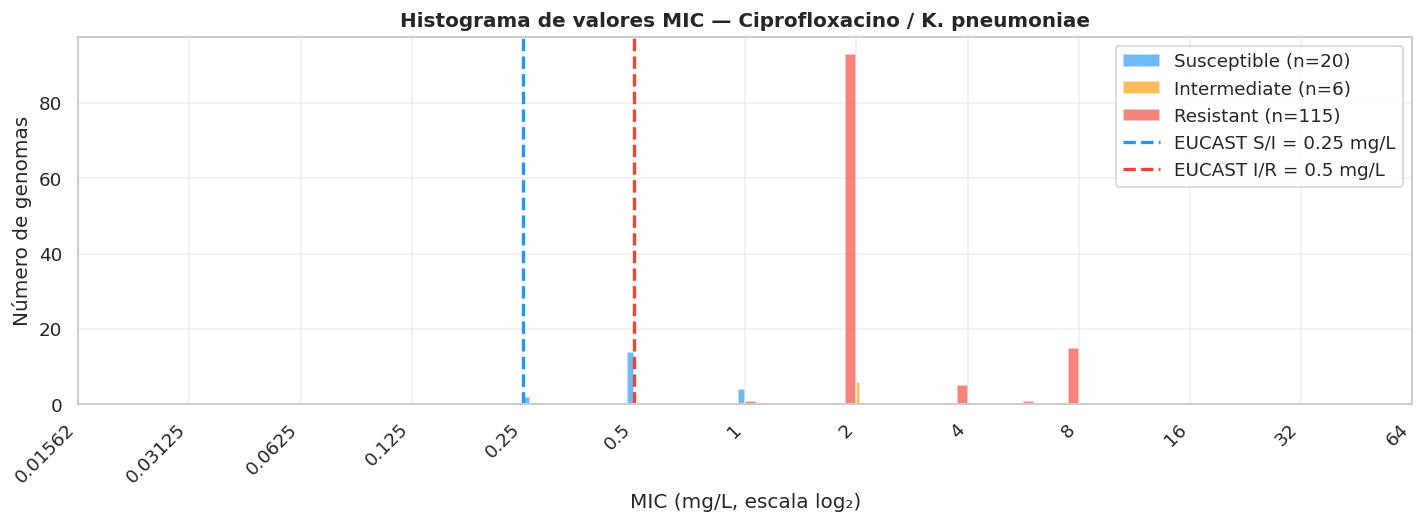

13:45:10 [INFO] Figura guardada → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/informes/figuras/03_histograma_mic.png


In [9]:
# ── 2e. Figura 4: Histograma de diluciones MIC ────────────────────────────────
#
# Los ensayos MIC reportan valores en diluciones dobles. Un histograma
# con eje log2 muestra la distribución real de los datos tal como
# salen del laboratorio.

fig, ax = plt.subplots(figsize=(12, 4.5))

for cat, color in COLORES_SIR.items():
    sub = df_mic[df_mic["resistant_phenotype"] == cat]["measurement_value"]
    if len(sub) == 0:
        continue
    ax.hist(
        np.log2(sub + 1e-6),  # log2 de los valores MIC
        bins=30, alpha=0.65, color=color,
        label=f"{cat} (n={len(sub)})", edgecolor="white"
    )

# Líneas de breakpoint en escala log2
ax.axvline(np.log2(EUCAST_S_MIC), color="#2196F3", linestyle="--", lw=2,
           label=f"EUCAST S/I = {EUCAST_S_MIC} mg/L")
ax.axvline(np.log2(EUCAST_R_MIC), color="#F44336", linestyle="--", lw=2,
           label=f"EUCAST I/R = {EUCAST_R_MIC} mg/L")

# Eje x con etiquetas MIC reales (mg/L)
ticks_log2 = np.arange(-6, 7, dtype=float)
ax.set_xticks(ticks_log2)
ax.set_xticklabels([f"{2**t:.4g}" for t in ticks_log2], rotation=45, ha="right")

ax.set_xlabel("MIC (mg/L, escala log₂)")
ax.set_ylabel("Número de genomas")
ax.set_title(
    "Histograma de valores MIC — Ciprofloxacino / K. pneumoniae",
    fontweight="bold"
)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
ruta_fig3 = DIR_FIGS / "03_histograma_mic.png"
plt.savefig(ruta_fig3, bbox_inches="tight", dpi=150)
plt.show()
log.info(f"Figura guardada → {ruta_fig3}")

---
## Celda 3 — Validación de consistencia MIC ↔ fenotipo

Detectamos genomas en los que el valor MIC reportado **contradice** el fenotipo S/R asignado
según los breakpoints EUCAST. Estas inconsistencias pueden deberse a:
- Errores de anotación en BV-BRC
- Metodologías de laboratorio distintas (e-test vs broth microdilution)
- Breakpoints de distintas ediciones de EUCAST o CLSI

Los genomas con inconsistencia MIC↔fenotipo se **excluirán** del dataset final.

In [10]:
# ── 3a. Detectar inconsistencias MIC ↔ fenotipo ───────────────────────────────
#
# Solo podemos validar los genomas que tienen MIC numérico Y fenotipo S o R.
# Para los Intermedios la inconsistencia es inherente al propio criterio.

df_val = df_mic[df_mic["resistant_phenotype"].isin(["Susceptible", "Resistant"])].copy()

def es_inconsistente(row):
    """True si el MIC contradice el fenotipo según breakpoints EUCAST."""
    mic     = row["measurement_value"]
    fenot   = row["resistant_phenotype"]
    signo   = row.get("measurement_sign", "=")

    # Para signos censurados usamos el valor reportado como límite
    # Susceptible debería tener MIC <= EUCAST_S_MIC
    if fenot == "Susceptible" and mic > EUCAST_R_MIC:
        return True   # MIC claramente en zona R, pero fenotipo S → inconsistente
    # Resistant debería tener MIC > EUCAST_R_MIC
    if fenot == "Resistant" and mic <= EUCAST_S_MIC:
        return True   # MIC en zona S, pero fenotipo R → inconsistente
    return False

df_val["inconsistente"] = df_val.apply(es_inconsistente, axis=1)

n_inc = df_val["inconsistente"].sum()
ids_inconsistentes = set(df_val[df_val["inconsistente"]]["genome_id"].astype(str))

print(f"Genomas con MIC numérico y fenotipo S/R: {len(df_val)}")
print(f"Inconsistencias MIC↔fenotipo detectadas: {n_inc}")

if n_inc > 0:
    print("\nEjemplos de inconsistencias:")
    cols_show = ["genome_id", "resistant_phenotype", "measurement_value", "measurement_sign"]
    print(df_val[df_val["inconsistente"]][cols_show].head(10).to_string(index=False))

Genomas con MIC numérico y fenotipo S/R: 135
Inconsistencias MIC↔fenotipo detectadas: 4

Ejemplos de inconsistencias:
genome_id resistant_phenotype  measurement_value measurement_sign
573.13705         Susceptible                1.0              NaN
573.14201         Susceptible                1.0              NaN
573.24279         Susceptible                1.0                =
573.24342         Susceptible                1.0               <=


In [11]:
# ── 3b. Resolver genomas con múltiples registros ──────────────────────────────
#
# Prioridad de fuente (de mayor a menor confianza):
#   1. Fenotipo S/R con MIC numérico consistente con EUCAST
#   2. Fenotipo S/R sin MIC (solo categoría clínica)
#   3. Fenotipo Intermediate (se resolverá en Celda 4)

def prioridad_fenotipo(fenot):
    return {"Susceptible": 0, "Resistant": 1, "Intermediate": 2}.get(fenot, 3)

df_cipro["_prioridad"] = df_cipro["resistant_phenotype"].map(prioridad_fenotipo)

# Para cada genome_id, quedarse con la fila de mayor prioridad (menor número)
df_dedup = (
    df_cipro
    .sort_values(["genome_id", "_prioridad"])
    .drop_duplicates(subset="genome_id", keep="first")
    .drop(columns=["_prioridad"])
    .reset_index(drop=True)
)

log.info(f"Tras deduplicación: {len(df_dedup)} genomas únicos")
print(f"Genomas únicos en df_dedup: {len(df_dedup)}")
print(f"\nDistribución S/I/R post-dedup:")
print(df_dedup["resistant_phenotype"].value_counts())

13:45:27 [INFO] Tras deduplicación: 565 genomas únicos


Genomas únicos en df_dedup: 565

Distribución S/I/R post-dedup:
resistant_phenotype
Susceptible    290
Resistant      275
Name: count, dtype: int64


---
## Celda 4 — Resolución de fenotipos Intermedios

**Opciones disponibles** (controladas por `ESTRATEGIA_I` en Celda 0):

| Estrategia | Descripción | Ventaja | Riesgo |
|---|---|---|---|
| `exclude` | Eliminar los I del dataset | Etiquetas más limpias, sin ambigüedad | Pierde datos (puede importar si I es numeroso) |
| `as_R` | Reclasificar I → Resistente | Máxima seguridad clínica (VME conservador) | Introduce ruido si algunos I son clínicamente S |

**Referencia:** EUCAST 2019 redefinió I como *Susceptible, Increased Exposure* (SIE).
Para fluoroquinolonas como ciprofloxacino, la zona I es muy estrecha (0.25–0.5 mg/L)
y en la práctica la mayoría de laboratorios reportan directamente S o R.

In [12]:
# ── 4a. Aplicar estrategia para Intermedios ────────────────────────────────────
n_intermedios = (df_dedup["resistant_phenotype"] == "Intermediate").sum()
print(f"Fenotipos Intermedios a resolver: {n_intermedios}")

if ESTRATEGIA_I == "exclude":
    df_final = df_dedup[df_dedup["resistant_phenotype"] != "Intermediate"].copy()
    log.info(f"Estrategia 'exclude': {n_intermedios} genomas eliminados")
elif ESTRATEGIA_I == "as_R":
    df_final = df_dedup.copy()
    mask_i = df_final["resistant_phenotype"] == "Intermediate"
    df_final.loc[mask_i, "resistant_phenotype"] = "Resistant"
    log.info(f"Estrategia 'as_R': {n_intermedios} Intermedios reclasificados como Resistant")
else:
    raise ValueError(f"ESTRATEGIA_I desconocida: {ESTRATEGIA_I!r}. Usa 'exclude' o 'as_R'.")

# ── 4b. Excluir también los genomas con inconsistencia MIC↔fenotipo ───────────
n_antes_exc = len(df_final)
df_final = df_final[~df_final["genome_id"].astype(str).isin(ids_inconsistentes)].copy()
n_excluidos_inc = n_antes_exc - len(df_final)

log.info(f"Genomas excluidos por inconsistencia MIC↔fenotipo: {n_excluidos_inc}")

print(f"\n{'─'*40}")
print(f"Genomas en df_final: {len(df_final)}")
print(f"  Excluidos por estrategia '{ESTRATEGIA_I}': {n_intermedios if ESTRATEGIA_I == 'exclude' else 0}")
print(f"  Excluidos por inconsistencia MIC↔fenotipo: {n_excluidos_inc}")
print(f"\nDistribución final S/R:")
print(df_final["resistant_phenotype"].value_counts())

# Ratio desbalance
vc = df_final["resistant_phenotype"].value_counts(normalize=True)
ratio_max = vc.max()
print(f"\nRatio mayoritaria/minoritaria: {ratio_max:.2f}")
if ratio_max > 0.65:
    print("⚠️  Desbalance notable (>65%) — usar class_weight='balanced' o scale_pos_weight en modelado")
else:
    print("✓ Clases razonablemente balanceadas")

13:45:34 [INFO] Estrategia 'exclude': 0 genomas eliminados
13:45:34 [INFO] Genomas excluidos por inconsistencia MIC↔fenotipo: 4


Fenotipos Intermedios a resolver: 0

────────────────────────────────────────
Genomas en df_final: 561
  Excluidos por estrategia 'exclude': 0
  Excluidos por inconsistencia MIC↔fenotipo: 4

Distribución final S/R:
resistant_phenotype
Susceptible    286
Resistant      275
Name: count, dtype: int64

Ratio mayoritaria/minoritaria: 0.51
✓ Clases razonablemente balanceadas


---
## Celda 5 — Construcción del target binario

Codificamos el target como entero:
- `0` → Susceptible
- `1` → Resistant

El orden de los genomas en `y_final.npy` define el orden de filas en la
matriz de features del notebook 04. El `target_metadata.csv` actúa como
índice de alineación entre ambas estructuras.

In [13]:
# ── 5a. Crear tabla de metadata del target ────────────────────────────────────
#
# Esta tabla es el contrato de alineación entre:
#   - y_final.npy  (array 1D de etiquetas)
#   - X_final.npz  (matriz de features, notebook 05)
# El índice de fila en y_final corresponde a la posición en genome_id_order.

# Columnas que intentamos recuperar (pueden no existir en todos los datasets BV-BRC)
COLS_META = [
    "genome_id",
    "resistant_phenotype",
    "measurement_value",
    "measurement_sign",
    "measurement_units",
    "laboratory_typing_method",
    "source",
]
cols_disponibles = [c for c in COLS_META if c in df_final.columns]

df_meta = df_final[cols_disponibles].copy()
df_meta["genome_id"] = df_meta["genome_id"].astype(str)

# Etiqueta binaria
df_meta["label"] = df_meta["resistant_phenotype"].map(
    {"Susceptible": 0, "Resistant": 1}
).astype(int)

# Fuente de la etiqueta: ¿tenía MIC o es solo categoría clínica?
df_meta["fuente_label"] = np.where(
    df_meta["measurement_value"].notna(), "MIC+fenotipo", "solo_fenotipo"
)

# Resetear índice para que coincida con el array numpy
df_meta = df_meta.reset_index(drop=True)

print(f"Shape df_meta: {df_meta.shape}")
print(f"\nDistribución de labels:")
print(df_meta["label"].value_counts().rename({0: "0 (S)", 1: "1 (R)"}))
print(f"\nFuente de etiqueta:")
print(df_meta["fuente_label"].value_counts())
print(f"\nPrimeras filas de df_meta:")
df_meta.head()

Shape df_meta: (561, 7)

Distribución de labels:
label
0 (S)    286
1 (R)    275
Name: count, dtype: int64

Fuente de etiqueta:
fuente_label
solo_fenotipo    495
MIC+fenotipo      66
Name: count, dtype: int64

Primeras filas de df_meta:


,genome_id,resistant_phenotype,measurement_value,measurement_sign,laboratory_typing_method,label,fuente_label
0,573.10076,Susceptible,NaN,NaN,NaN,0,solo_fenotipo
1,573.10077,Susceptible,NaN,NaN,NaN,0,solo_fenotipo
2,573.10085,Susceptible,NaN,NaN,NaN,0,solo_fenotipo
3,573.12461,Resistant,NaN,NaN,NaN,1,solo_fenotipo
4,573.12465,Resistant,NaN,NaN,NaN,1,solo_fenotipo


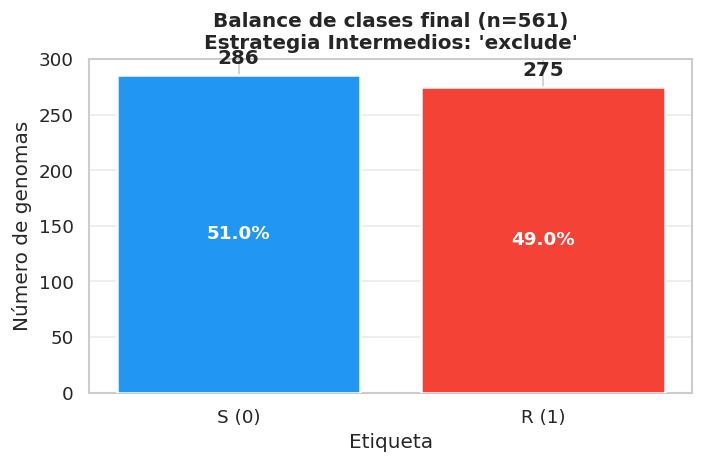

13:45:43 [INFO] Figura guardada → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/informes/figuras/03_balance_clases_final.png


In [14]:
# ── 5b. Figura 5: Balance de clases final ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

vc_label = df_meta["label"].value_counts().sort_index()
colores_bin = ["#2196F3", "#F44336"]
barras = ax.bar(
    ["S (0)", "R (1)"],
    vc_label.values,
    color=colores_bin, edgecolor="white", linewidth=1.5, zorder=3
)
ax.bar_label(barras, fmt="%d", padding=4, fontsize=12, fontweight="bold")

total = vc_label.sum()
for i, (bar, val) in enumerate(zip(barras, vc_label.values)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{val/total*100:.1f}%",
        ha="center", va="center", fontsize=11, color="white", fontweight="bold"
    )

ax.set_title(
    f"Balance de clases final (n={total})\n"
    f"Estrategia Intermedios: '{ESTRATEGIA_I}'",
    fontweight="bold"
)
ax.set_ylabel("Número de genomas")
ax.set_xlabel("Etiqueta")
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
ruta_fig4 = DIR_FIGS / "03_balance_clases_final.png"
plt.savefig(ruta_fig4, bbox_inches="tight", dpi=150)
plt.show()
log.info(f"Figura guardada → {ruta_fig4}")

In [15]:
# ── 5c. Sanity check final antes de guardar ───────────────────────────────────
#
# Verificamos que:
# 1. No hay NaN en la columna label
# 2. Solo valores {0, 1}
# 3. Todos los genome_id son únicos
# 4. Todos los IDs están en ids_qc_ok

assert df_meta["label"].isna().sum() == 0, "❌ Hay NaN en label"
assert set(df_meta["label"].unique()) <= {0, 1}, "❌ Valores fuera de {0, 1} en label"
assert df_meta["genome_id"].nunique() == len(df_meta), "❌ Genome IDs duplicados"
assert df_meta["genome_id"].isin(ids_qc_ok).all(), "❌ Hay IDs no presentes en ids_qc_ok"

print("✓ Todos los sanity checks superados")
print(f"  → {len(df_meta)} genomas con etiqueta binaria limpia")
print(f"  → Susceptible: {(df_meta['label']==0).sum()} | Resistant: {(df_meta['label']==1).sum()}")

✓ Todos los sanity checks superados
  → 561 genomas con etiqueta binaria limpia
  → Susceptible: 286 | Resistant: 275


---
## Celda 6 — Guardado de outputs

| Archivo | Descripción | Consumidor |
|---|---|---|
| `y_final.npy` | Array (N,) int — etiquetas 0/1 | notebooks 06, 07, 08 |
| `target_metadata.csv` | Tabla de alineación genome_id ↔ label ↔ MIC | notebooks 05, 06, 09 |
| `informe_target.json` | Resumen reproducible del proceso | auditoría |

> **Orden crítico:** La posición i-ésima de `y_final.npy` corresponde al
> `genome_id` en la fila i de `target_metadata.csv`. El notebook 05
> (matriz_features) **debe respetar este orden** al construir X.

In [17]:
# ── 6a. Guardar y_final.npy ───────────────────────────────────────────────────
y_final = df_meta["label"].to_numpy(dtype=np.int8)

ruta_y = DIR_PROC / "y_final.npy"
np.save(ruta_y, y_final)
log.info(f"y_final.npy guardado → {ruta_y}  shape={y_final.shape}  dtype={y_final.dtype}")

# ── 6b. Guardar target_metadata.csv ──────────────────────────────────────────
ruta_meta = DIR_PROC / "target_metadata.csv"
df_meta.to_csv(ruta_meta, index=False)
log.info(f"target_metadata.csv guardado → {ruta_meta}  shape={df_meta.shape}")

# ── 6c. Guardar informe JSON ──────────────────────────────────────────────────
vc_final = {int(k): int(v) for k, v in df_meta["label"].value_counts().to_dict().items()}

informe = {
    "timestamp"             : datetime.now().isoformat(),
    "antibiotico"           : ANTIBIOTICO,
    "breakpoints_eucast"    : {
        "version"           : "v14.0",
        "organismo"         : "Klebsiella pneumoniae",
        "S_mic_leq"         : float(EUCAST_S_MIC),
        "R_mic_gt"          : float(EUCAST_R_MIC),
        "unidades"          : "mg/L"
    },
    "estrategia_intermedios": ESTRATEGIA_I,
    "n_total_input"         : int(len(df_cipro)),
    "n_intermedios"         : int(n_intermedios),
    "n_inconsistentes_mic"  : int(n_excluidos_inc),
    "n_final"               : int(len(df_meta)),
    "distribucion_final"    : {
        "Susceptible (0)"   : vc_final.get(0, 0),
        "Resistant (1)"     : vc_final.get(1, 0),
    },
    "pct_con_mic"           : float(round(df_meta["measurement_value"].notna().mean() * 100, 1)),
    "archivos": {
        "y_final"           : str(ruta_y),
        "target_metadata"   : str(ruta_meta),
    }
}

ruta_inf = DIR_PROC / "informe_target.json"
with open(ruta_inf, "w") as f:
    json.dump(informe, f, indent=2, ensure_ascii=False)

print(json.dumps(informe, indent=2, ensure_ascii=False))
log.info(f"Informe guardado → {ruta_inf}")

13:47:06 [INFO] y_final.npy guardado → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/y_final.npy  shape=(561,)  dtype=int8
13:47:06 [INFO] target_metadata.csv guardado → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/target_metadata.csv  shape=(561, 7)
13:47:06 [INFO] Informe guardado → /mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/informe_target.json


{
  "timestamp": "2026-03-18T13:47:06.176486",
  "antibiotico": "ciprofloxacin",
  "breakpoints_eucast": {
    "version": "v14.0",
    "organismo": "Klebsiella pneumoniae",
    "S_mic_leq": 0.25,
    "R_mic_gt": 0.5,
    "unidades": "mg/L"
  },
  "estrategia_intermedios": "exclude",
  "n_total_input": 744,
  "n_intermedios": 0,
  "n_inconsistentes_mic": 4,
  "n_final": 561,
  "distribucion_final": {
    "Susceptible (0)": 286,
    "Resistant (1)": 275
  },
  "pct_con_mic": 11.8,
  "archivos": {
    "y_final": "/mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/y_final.npy",
    "target_metadata": "/mnt/c/Users/Alumno1/ablda/amr-resistance-prediction/datos/procesados/target_metadata.csv"
  }
}


---
## Celda 7 — Verificación de los archivos guardados

Carga inmediata para confirmar que los archivos se escribieron y leen correctamente.

In [18]:
# ── Verificación de integridad post-guardado ──────────────────────────────────
y_check    = np.load(DIR_PROC / "y_final.npy")
meta_check = pd.read_csv(DIR_PROC / "target_metadata.csv", dtype={"genome_id": str})

print("── y_final.npy ──────────────────────────────────────")
print(f"  shape  : {y_check.shape}")
print(f"  dtype  : {y_check.dtype}")
print(f"  únicos : {np.unique(y_check, return_counts=True)}")

print("\n── target_metadata.csv ──────────────────────────────")
print(f"  shape     : {meta_check.shape}")
print(f"  columnas  : {meta_check.columns.tolist()}")

# Verificar alineación: el orden de genome_id en meta_check debe coincidir
# con el orden en que se guardó y_final
assert len(y_check) == len(meta_check), "❌ Longitud no coincide"
assert (y_check == meta_check["label"].to_numpy()).all(), "❌ Desalineación entre y y metadata"

print("\n✓ y_final.npy y target_metadata.csv correctamente alineados")
print(f"\n{'='*50}")
print("RESUMEN DEL NOTEBOOK 03")
print(f"{'='*50}")
print(f"  Genomas de entrada (post-QC)   : {len(ids_qc_ok)}")
print(f"  Genomas con fenotipo cipro     : {len(df_cipro)}")
print(f"  Intermedios ({ESTRATEGIA_I:<7})        : {n_intermedios}")
print(f"  Inconsistencias MIC↔fenotipo   : {n_excluidos_inc}")
print(f"  Dataset final                  : {len(y_check)} genomas")
print(f"    Susceptible (0)              : {(y_check == 0).sum()}")
print(f"    Resistant   (1)              : {(y_check == 1).sum()}")
print(f"\n  Siguiente paso → notebook 04: extracción de k-mers")

── y_final.npy ──────────────────────────────────────
  shape  : (561,)
  dtype  : int8
  únicos : (array([0, 1], dtype=int8), array([286, 275]))

── target_metadata.csv ──────────────────────────────
  shape     : (561, 7)
  columnas  : ['genome_id', 'resistant_phenotype', 'measurement_value', 'measurement_sign', 'laboratory_typing_method', 'label', 'fuente_label']

✓ y_final.npy y target_metadata.csv correctamente alineados

RESUMEN DEL NOTEBOOK 03
  Genomas de entrada (post-QC)   : 565
  Genomas con fenotipo cipro     : 744
  Intermedios (exclude)        : 0
  Inconsistencias MIC↔fenotipo   : 4
  Dataset final                  : 561 genomas
    Susceptible (0)              : 286
    Resistant   (1)              : 275

  Siguiente paso → notebook 04: extracción de k-mers
